# 02_weather_and_fundamentals

### Research Question:

How do temperature and wind conditions affect Alberta electricity prices, demand, and scarcity events?

The Alberta grid is increasingly weather-driven. Electricity demand responds to temperature, while renewable generation responds to wind and solar resource availability. Understanding these relationships is essential for forecasting prices, assessing system stress, and evaluating future renewable integration.

#### Data Overview

In [3]:
from load_data import load_model_data

df = load_model_data()

print(df.shape)
df.head()

(48935, 67)


,timestamp,pool_price,demand,IMPORT_BC,IMPORT_MT,IMPORT_SK,EXPORT_BC,EXPORT_MT,EXPORT_SK,calgary_temperature_2m,...,abs_demand_ramp,net_load,net_load_ramp,abs_net_load_ramp,gen_ramp,abs_gen_ramp,ramp_stress,total_imports,import_dependence,balance_check
0,2020-01-01 00:00:00,30.24,9467,0,80,0,0,0,0,0.55,...,NaN,8588.448551,NaN,NaN,NaN,NaN,NaN,80,0.008450,-2743.531609
1,2020-01-01 01:00:00,29.43,9361,0,125,0,0,0,0,-0.20,...,106.0,8577.784060,-10.664491,10.664491,-127.208351,127.208351,0.001139,125,0.013353,-2719.739960
2,2020-01-01 02:00:00,29.66,9286,0,125,0,0,0,0,-0.50,...,75.0,8565.784713,-11.999348,11.999348,-89.532789,89.532789,0.001292,125,0.013461,-2734.272748
3,2020-01-01 03:00:00,28.19,9209,0,125,0,0,0,0,-1.55,...,77.0,8507.977929,-57.806784,57.806784,-64.027290,64.027290,0.006277,125,0.013574,-2721.300039
4,2020-01-01 04:00:00,31.17,9195,0,125,0,0,0,0,-2.10,...,14.0,8630.764032,122.786104,122.786104,-25.196383,25.196383,0.013354,125,0.013594,-2732.496422


why this matters:

this dataset combines serveral major componenets of the alberta electricity system:
- pool prices
- electricity demand
- intertie imports/exports
- weather observations
- natural gas prices
- generation by fuel type
- engineered system features

unlike a simple market dataset, this allows us to study both demand-side and supply-side drivers of electricity prices. 

can weather variables explain meaningful portions of alberta's price behaviour?

#### weather variable summary statistics

Question:

what weather conditions does alberta experience over the sample period?

In [4]:
cols = [
    "HDD",
    "CDD",
    "wind_index",
    "pool_price"
]

df[cols].describe()

,HDD,CDD,wind_index,pool_price
count,48935.000000,48935.000000,48935.000000,48935.000000
mean,13.943349,0.544076,5.955258,94.942801
std,11.114886,1.847686,2.900504,153.904992
min,0.000000,0.000000,0.150000,0.000000
25%,4.550000,0.000000,3.679049,30.570000
50%,13.100000,0.000000,5.553602,45.310000
75%,20.700000,0.000000,7.950212,78.760000
max,57.400000,16.100000,20.868429,999.990000


findings:

heating dominates cooling. alberta is primarily a heating-driven jurisdiction. most hours require heating demand, while relatively few require significant cooling demand. 

sourthern alberta is consistenly windy - and it turn, it has become Canada's largest wind development region. weather exposure in alberta is asymmetric:
- demand is mostly affected by cold weather
- renewable generation is mostly affected by wind condidtions

#### Seasonal Weather Patterns

Question:

how do weather conditions evolve throughout the year?

<Axes: xlabel='month'>

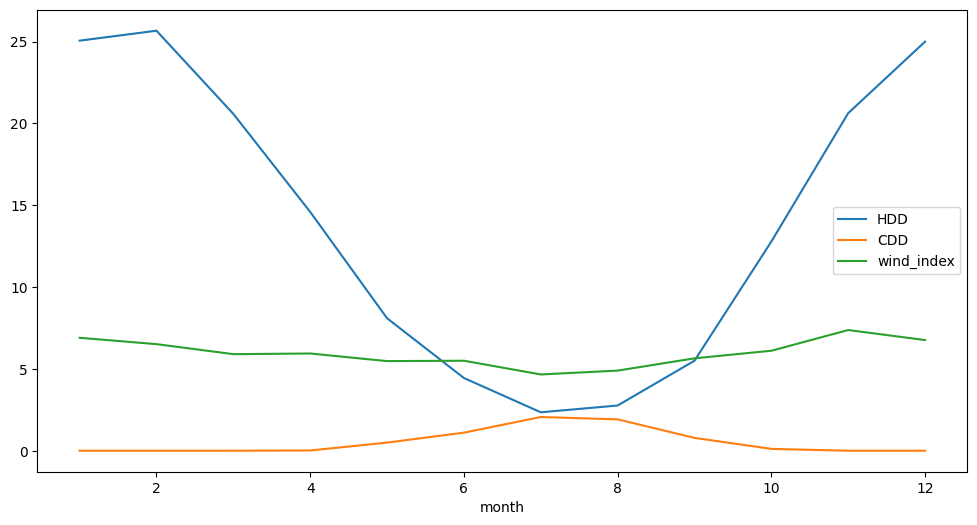

In [5]:
monthly_weather = (
    df.groupby("month")
    [["HDD","CDD","wind_index"]]
    .mean()
)

monthly_weather.plot(
    figsize=(12,6)
)

findings:

expected seasonal structure emerges

winter: 
- high HDD
- low CDD

summer:
- high CDD
- low HDD

but HDD is massively more meaningful than CDD - which remains low but peaks around july. wind varies seasonally but remains relatively stable throughout the year, peaking in november. 

seasonality creates recurring market regimes. 

the system behaves fundamentally differently in: 
- winter cold snaps
- summer heat waves
- spring shoulder months
- fall shoulder months

#### Correlation Analysis

Question:

which weather variables show the strongest relationship with electricity prices?

In [6]:
corr = df[
    [
        "pool_price",
        "demand",
        "HDD",
        "CDD",
        "wind_index"
    ]
].corr()

In [7]:
print(
    corr["pool_price"]
    .sort_values(ascending=False)
)

pool_price    1.000000
CDD           0.281782
demand        0.216091
HDD           0.074327
wind_index   -0.273511
Name: pool_price, dtype: float64


findings:

high temperatures tend to coincide with higher electricity prices. this was the strongest positive weather relationship found. 

high wind speeds tend to coincide with lower electricity prices - which is exactly what economic theory predicts:

more wind generation --> more supply --> lower marginal generator costs --> lower pool prices

higher demand generally increases prices, but the relationship is weaker than expected. demand alone does not drive scarcity. 

alberta's system is designed around winter operation, therefore winter demand is:
- predictable
- planned for
- supported by thermal
as so its no surprise that HDD is relatively weak compared to CDD.

the supply-side effect of wind appears nearly as important as the demand-side effect of temperature. 

#### Scatter Plot Analysis

Question:

does hotter weather visibly increase prices?

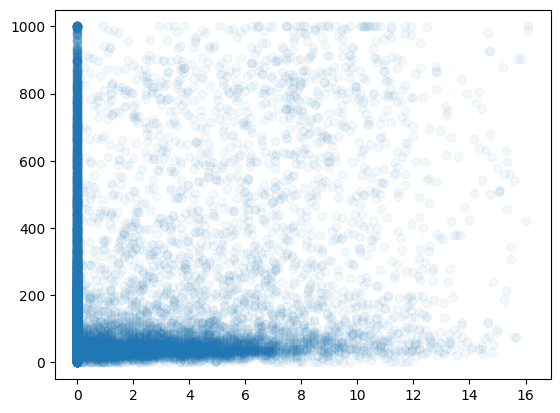

In [8]:
plt.scatter(
    df["CDD"],
    df["pool_price"],
    alpha=0.05
)

Findings:

The scatter plot reveals a highly concentrated distribution with a pronounced vertical cluster at CDD = 0, confirming that the vast majority of hours in Alberta occur at or below the cooling threshold — consistent with a northern climate where air conditioning demand is the exception rather than the rule.

For the non-zero CDD observations, prices are widely dispersed across the full range (0–1000 $/MWh) at virtually every CDD value up to ~16. This diffuse cloud suggests that hotter weather alone does not reliably predict high prices — the correlation (r = 0.28) is real but modest, and the scatter makes clear why.

A few additional patterns stand out:

Price spikes are not CDD-gated. Extreme prices (>400 $/MWh) appear at CDD = 0 just as readily as at CDD = 10+, meaning scarcity events are driven by factors beyond heat — unplanned outages, low wind, or demand surges — rather than temperature alone.

The density gradient slopes downward. The darkest, most opaque region sits at low CDD and low price, then thins out toward higher CDD values. This is consistent with the positive correlation: higher CDD hours do shift the conditional price distribution upward on average, but the effect is buried in variance.

The relationship is asymmetric. CDD has a hard floor at zero by construction, so the variable captures intensity of heat but not its absence. This compression at zero inflates the vertical cluster and likely understates the true sensitivity of prices to cooling load once the threshold is crossed.

CDD is a useful signal but not a sufficient one. The wide price dispersion at every CDD level reinforces that Alberta's pool price is driven by a confluence of supply and demand factors — wind availability, thermal outages, and demand peaks — rather than temperature in isolation.

Question:

Does wind surppress prices?

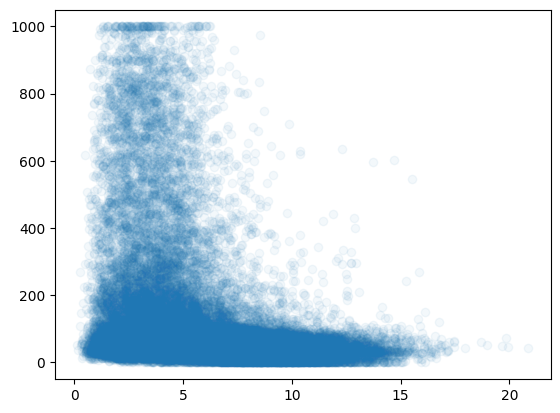

In [9]:
plt.scatter(
    df["wind_index"],
    df["pool_price"],
    alpha=0.05
)

Findings:

Unlike the CDD scatter which was dominated by a zero-floor cluster, this plot has much better coverage across the x-axis — wind is always blowing to some degree in Alberta, so every hour registers a non-zero wind index. This makes the visual relationship cleaner and more interpretable.

The price ceiling drops sharply as wind increases. This is the most striking feature of the plot. At low wind index values (0–5), prices span the full range up to 1000 $/MWh. By wind index ~10, the upper bound of observed prices has fallen considerably, and by ~15+, extreme spikes have nearly disappeared entirely. This is a visible, structural suppression effect — not just a subtle shift in averages.

The dense core confirms the correlation. The darkest mass of points sits at low wind and low-to-moderate prices, but the gradient is clear: as wind increases, the probability of a high-price outcome shrinks. This is the merit-order effect in action — wind generation has near-zero marginal cost, so it displaces higher-cost thermal generation and pulls the market clearing price down.

Price spikes require low wind. Observations above 400 $/MWh are almost exclusively concentrated below a wind index of ~8. This suggests that scarcity pricing in Alberta is not just correlated with low wind — low wind may be a near-necessary condition for extreme price events.

The floor remains flat. Minimum prices hover near zero regardless of wind level, meaning wind suppresses the upside of the price distribution far more than it affects the baseline. This is consistent with how Alberta's energy-only market works — prices can always fall to near zero when supply is abundant.

The wind scatter tells a more compelling visual story than CDD did. The downward-sloping price ceiling is a textbook illustration of supply-side price suppression, and it reinforces that wind index belongs in any serious model of Alberta pool price — particularly for forecasting scarcity and spike risk.

#### CDD Bucket Analysis

Question: 

how does price change as temperatures become increasingly hot?

In [10]:
df["CDD_bucket"] = pd.cut(
    df["CDD"],
    bins=[0,5,10,15,20]
)

df.groupby(
    "CDD_bucket"
)["pool_price"].mean()

CDD_bucket
(0, 5]      126.515719
(5, 10]     252.916173
(10, 15]    358.669192
(15, 20]    532.064762
Name: pool_price, dtype: float64

findings:

prices rise dramatically with higher cooling demand. average price more than quadruples between mild and extremely hot conditions. 

interpretation:

this is stronger evidence than simple correlation. extreme heat creates disproportionate price impacts. the relationship also appears nonlinear. moving from CDD = 2 --> CDD = 12 has a much large effect than a simple linear model would suggest. 

In [19]:
df['wind_bucket'] = pd.qcut(
    df['wind_index'],
    q=4,
    labels=['Q1_low', 'Q2', 'Q3', 'Q4_high']
)

df.groupby(
    'wind_bucket'
)['pool_price'].mean()

wind_bucket
Q1_low     156.765266
Q2         114.125795
Q3          65.778163
Q4_high     43.099598
Name: pool_price, dtype: float64

mean pool price falls monotonically as wind increases, and the magnitude of this effect is substantial. 

the spread is nearly 4x from through to peak. Q1 hours average $156/MWh versus $43/MWh in Q4 - a $113/MWh difference driven purely by wind regime. this is not a marginal effect; it represents a structural shift in the price distribution depending on how hard the wind is blowing in Lethbridge and Medicine Hat. 

the relationship is monotonic and roughly linear in decline. each quartile step down in wind corresponds to a meaningful price incresase, with the sharpest jump occcurring between Q3 and Q2 ($48/MWh), suggesting a threshold around median wind speeds where the merit-order suppression effect begins to weaken meaningfully. 

This strengthens the case for wind as a core model feature. The correlation (r = -0.27) understated the practical importance of the variable — a near 4x price differential across quartiles is a signal most demand-side features can't match. Wind index likely belongs in any feature set aimed at forecasting price level or spike probability.

Caveat: wind_index is a simple two-station average (Lethbridge + Medicine Hat) and may not fully represent curtailment, transmission constraints, or wind generation across the full Alberta grid. A renewable_share or gen_wind feature from the generation mix data may ultimately be a stronger predictor since it captures actual injected generation rather than a proxy wind speed.


#### Scarcity Analysis

Question:

what weather conditions characterize scarcity events?

In [12]:
df["scarcity"] = (
    df["pool_price"] > 300
).astype(int)

In [13]:
df.groupby("scarcity")[
    [
        "CDD",
        "HDD",
        "wind_index"
    ]
].mean()

,CDD,HDD,wind_index
scarcity,,,
0,0.419558,13.788290,6.125328
1,2.184705,15.986385,3.714438


findings:

scarcity hours are:
- hotter
- slightly colder
- dramatically less windy

the strongest difference is wind, which falls from 6.13 to 3.71 during scarcity events. low wind appears to be more important than temperature. Alberta scarcity might fundamentally be a low-renewable problem. 

#### Extreme Heat Analysis

Question:

what happens during alberta's hottest hours?

In [16]:
hot_hours = df[df["CDD"] > df["CDD"].quantile(0.95)]

hot_hours["pool_price"].describe()

count    2445.000000
mean      261.860560
std       297.359719
min         0.000000
25%        43.070000
50%        95.120000
75%       439.590000
max       999.990000
Name: pool_price, dtype: float64

findigns:

extreme heat substantially increases price risk. however, not every hot hour produces scarcity. 

interpreatation:

heat increases the probability of scarcity, but it does not guarantee scarcity. other system conditions still matter here.

#### Low Wind Analysis

Question:

what happens when alberta's wind resource is unusually weak?

In [17]:
low_wind = df[
    df["wind_index"] <
    df["wind_index"].quantile(0.05)
]

low_wind["pool_price"].describe()

count    2447.000000
mean      167.744279
std       214.261504
min         3.970000
25%        38.030000
50%        70.000000
75%       189.680000
max       999.990000
Name: pool_price, dtype: float64

findings:

low-wind periods exhibit significantly elevated prics. even without considering demand, low wind alone creates substantial upward price pressure. 

interpretation: 

wind genreation is become a critical component of Alberta's market behaviour. when wind output collapses:
- renewable supply disappears
- dispatchzble genreation requirements increase
- reserve margins tighten
- scarcity risk rises